In [ ]:
from google.colab import drive
import os

# 1. Mount the Google Drive
drive.mount('/content/drive')

# 2. Define the exact path to the shared project folder
PROJECT_ROOT = '/content/drive/MyDrive/MNIST-Project/'

# 3. Automatically create the required sub-folders if they don't exist yet
os.makedirs(os.path.join(PROJECT_ROOT, 'data'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'models'), exist_ok=True)
os.makedirs(os.path.join(PROJECT_ROOT, 'results'), exist_ok=True)

print("Drive successfully mounted and project directories are ready!")

Mounted at /content/drive
Drive successfully mounted and project directories are ready!


In [ ]:
import numpy as np
import os
from tensorflow.keras.datasets import mnist

print("Downloading MNIST Dataset...")
# The load_data() function automatically downloads the dataset
# and unpacks it into train and test tuples.
(x_train_raw, y_train), (x_test_raw, y_test) = mnist.load_data()

print(f"Original Training shape: {x_train_raw.shape}")
print(f"Original Testing shape: {x_test_raw.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Original Training shape: (60000, 28, 28)
Original Testing shape: (10000, 28, 28)


In [ ]:
print("Normalizing pixel values...")
# We convert the integers to floats and divide by 255.0.
# Now all pixel values are strictly between 0.0 and 1.0.
x_train_norm = x_train_raw.astype('float32') / 255.0
x_test_norm = x_test_raw.astype('float32') / 255.0

print(f"Max pixel value after normalization: {np.max(x_train_norm)}")

Normalizing pixel values...
Max pixel value after normalization: 1.0


In [ ]:
print("Flattening images for SVM compatibility...")
# We use reshape to change (60000, 28, 28) into (60000, 784)
x_train_flat = x_train_norm.reshape(x_train_norm.shape[0], -1)
x_test_flat = x_test_norm.reshape(x_test_norm.shape[0], -1)

print(f"Flattened Training shape: {x_train_flat.shape}")

Flattening images for SVM compatibility...
Flattened Training shape: (60000, 784)


In [ ]:
print("Explicitly shuffling data to ensure random distribution...")

# 1. Generate a randomized list of index numbers from 0 to 59,999
random_indices = np.random.permutation(len(x_train_flat))

# 2. Apply that exact same random order to ALL arrays so they stay aligned
x_train_flat_shuffled = x_train_flat[random_indices]
x_train_2d_shuffled = x_train_norm[random_indices]
y_train_shuffled = y_train[random_indices]

print("Creating experimental data splits from shuffled data...")

# 1. The "Small" Split (5,000 randomly distributed images)
x_train_5k_flat = x_train_flat_shuffled[:5000]
x_train_5k_2d = x_train_2d_shuffled[:5000]
y_train_5k = y_train_shuffled[:5000]

# 2. The "Medium" Split (15,000 randomly distributed images)
x_train_15k_flat = x_train_flat_shuffled[:15000]
x_train_15k_2d = x_train_2d_shuffled[:15000]
y_train_15k = y_train_shuffled[:15000]

print("Splits created successfully!")

Explicitly shuffling data to ensure random distribution...
Creating experimental data splits from shuffled data...
Splits created successfully!


In [ ]:
data_dir = os.path.join(PROJECT_ROOT, 'data')

print("Saving preprocessed and shuffled data to shared Drive...")

# 1. Save the Testing Data
np.save(os.path.join(data_dir, 'x_test_flat.npy'), x_test_flat)
np.save(os.path.join(data_dir, 'x_test_2d.npy'), x_test_norm)
np.save(os.path.join(data_dir, 'y_test.npy'), y_test)

# 2. Save the FULL Training Data
np.save(os.path.join(data_dir, 'y_train_full.npy'), y_train_shuffled)
np.save(os.path.join(data_dir, 'x_train_full_flat.npy'), x_train_flat_shuffled)
np.save(os.path.join(data_dir, 'x_train_full_2d.npy'), x_train_2d_shuffled)

# 3. Save the SVM (Flattened) Splits
np.save(os.path.join(data_dir, 'x_train_5k_flat.npy'), x_train_5k_flat)
np.save(os.path.join(data_dir, 'x_train_15k_flat.npy'), x_train_15k_flat)

# 4. Save the CNN (2D) Splits
np.save(os.path.join(data_dir, 'x_train_5k_2d.npy'), x_train_5k_2d)
np.save(os.path.join(data_dir, 'x_train_15k_2d.npy'), x_train_15k_2d)

# 5. Save the Split Labels
np.save(os.path.join(data_dir, 'y_train_5k.npy'), y_train_5k)
np.save(os.path.join(data_dir, 'y_train_15k.npy'), y_train_15k)

print("All shuffled data saved successfully to /data folder!")

Saving preprocessed and shuffled data to shared Drive...
All shuffled data saved successfully to /data folder!


In [ ]:
from sklearn.decomposition import PCA
import numpy as np

# Load perfectly shuffled data
print("Loading pre-shuffled Day 1 data from Drive...")
data_dir = os.path.join(PROJECT_ROOT, 'data')
x_train_full_flat = np.load(os.path.join(data_dir, 'x_train_full_flat.npy'))
x_test_flat = np.load(os.path.join(data_dir, 'x_test_flat.npy'))

print("--- Running PCA (85% Variance) ---")
# Tell PCA to keep components until 85% of the information is captured
pca = PCA(n_components=0.85)

# Fit the math ONLY on the full 60k training data to prevent data leakage
pca.fit(x_train_full_flat)

optimal_components = pca.n_components_
print(f"Optimal components selected to retain 85% variance: {optimal_components}")

# Compress both the training and test sets
print("Compressing datasets...")
x_train_pca = pca.transform(x_train_full_flat)
x_test_pca = pca.transform(x_test_flat)

# Save the newly compressed data to the shared Drive
print("Saving PCA-transformed data to Drive...")
np.save(os.path.join(data_dir, 'x_train_pca.npy'), x_train_pca)
np.save(os.path.join(data_dir, 'x_test_pca.npy'), x_test_pca)
print("PCA Data saved! Member 1 can now load this for the custom SVM.")

Loading pre-shuffled Day 1 data from Drive...
--- Running PCA (85% Variance) ---
Optimal components selected to retain 85% variance: 59
Compressing datasets...
Saving PCA-transformed data to Drive...
PCA Data saved! Member 1 can now load this for the custom SVM.


--- Generating t-SNE Visualization ---


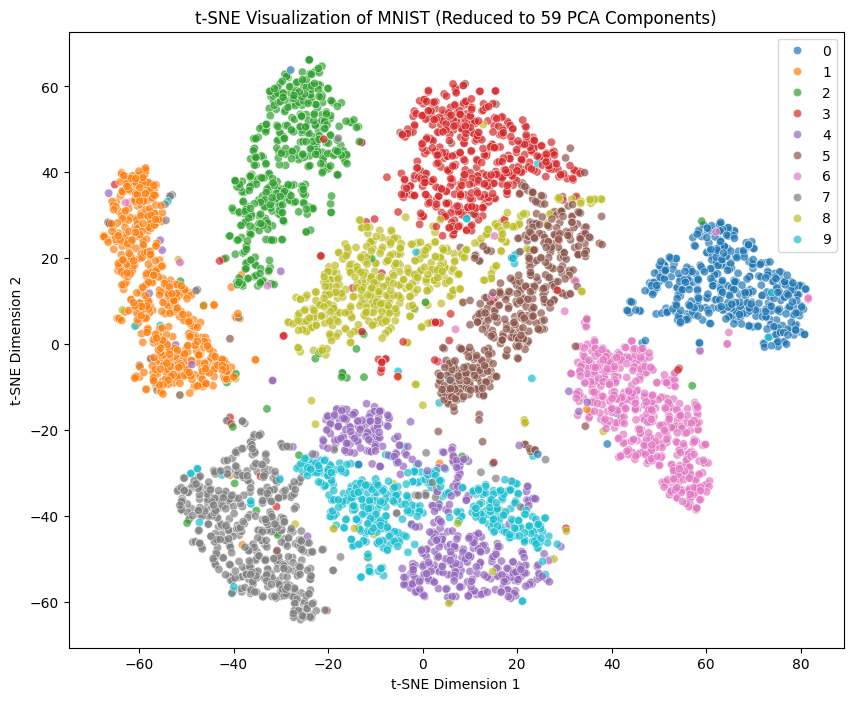

t-SNE plot successfully saved to: /content/drive/MyDrive/MNIST-Project/results/tsne_plot.png


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("--- Generating t-SNE Visualization ---")

# 1. Load the perfectly shuffled labels from Drive backup
y_train_full = np.load(os.path.join(data_dir, 'y_train_full.npy'))

# 2. Feed the first 5000 PCA points into t-SNE
tsne = TSNE(n_components=2, random_state=1)
x_tsne = tsne.fit_transform(x_train_pca[:5000])

# 3. Grab the matching 5000 labels for the colors!
y_tsne = y_train_full[:5000]

# Plotting the graph
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=x_tsne[:, 0], y=x_tsne[:, 1],
    hue=y_tsne,
    palette=sns.color_palette("tab10", 10),
    legend='full',
    alpha=0.7
)

plt.title(f't-SNE Visualization of MNIST (Reduced to {optimal_components} PCA Components)')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')

# Save the high-quality image directly to the 'results' folder on Drive
results_dir = os.path.join(PROJECT_ROOT, 'results')
plot_path = os.path.join(results_dir, 'tsne_plot.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"t-SNE plot successfully saved to: {plot_path}")